# Нормализация и стандартизация признаков фильмов

**Решение преподавателя. Продолжительность: 90 минут.**

Все примеры строятся на `MoviesOnStreamingPlatforms.csv`. Для масштабирования используем только содержательные числовые признаки, созданные из исходных полей:

**Источник датасета:** [https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv](https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv)


- рейтинг;
- возраст фильма;
- длина названия;
- число платформ;
- минимальный возраст зрителя.

`movie_id` не масштабируется: это идентификатор, а не измеряемая характеристика.

In [1]:
# -----------------------------------------------------------------------------
# Назначение ячейки: подготовить окружение и пути для воспроизводимого запуска.
# Вывод версий библиотек помогает диагностировать различия между VS Code и Colab.
# Функция поиска корня проекта исключает необходимость вручную менять пути к файлам.
# Результат: корректные пути к исходным данным, обработанным данным и графикам.
# -----------------------------------------------------------------------------

from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем, выполняется ли notebook в Google Colab.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Python:", sys.version.split()[0])
print("Операционная система:", platform.system())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Google Colab:", IN_COLAB)
print("Текущая рабочая папка:", Path.cwd())


def find_project_root() -> Path:
    """Ищет папку пары по наличию исходного CSV.

    Функция позволяет запускать notebook:
    - из корня папки пары;
    - из подпапки notebooks в VS Code или Jupyter;
    - в Google Colab после распаковки папки пары в /content.
    """
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    marker = Path("data/raw/MoviesOnStreamingPlatforms.csv")
    for candidate in candidates:
        if (candidate / marker).exists():
            return candidate

    # Дополнительные типовые расположения для Google Colab.
    colab_candidates = [
        Path('/content'),
        Path('/content/01_types_and_reshape'),
        Path('/content/02_aggregation_and_datamart'),
        Path('/content/03_scaling_methods'),
        Path('/content/04_reproducible_preprocessing'),
    ]
    for candidate in colab_candidates:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Не найден data/raw/MoviesOnStreamingPlatforms.csv. "
        "Распакуйте архив пары целиком и запустите notebook повторно."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "MoviesOnStreamingPlatforms.csv"
print("Корень проекта:", PROJECT_ROOT)
print("Исходный файл:", DATA_PATH)

Python: 3.10.5
Операционная система: Windows
pandas: 2.0.1
NumPy: 1.23.5
Google Colab: False
Текущая рабочая папка: d:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.1 Нормализация и стандартизация данных\notebooks
Корень проекта: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.1 Нормализация и стандартизация данных
Исходный файл: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.1 Нормализация и стандартизация данных\data\raw\MoviesOnStreamingPlatforms.csv


In [2]:
# -----------------------------------------------------------------------------
# Назначение ячейки: подготовить каталог фильмов и создать числовые признаки.
# Функция повторяет единые правила очистки для всего учебного дня, чтобы сравнение
# методов масштабирования выполнялось на тех же данных и тех же признаках.
# Особенно важны rating_score, movie_age, title_length, platform_count и age_min.
# -----------------------------------------------------------------------------

def prepare_movies(df: pd.DataFrame) -> pd.DataFrame:
    """Подготавливает каталог фильмов для анализа.

    Параметры
    ---------
    df : pd.DataFrame
        Исходная таблица без предварительного изменения.

    Возвращает
    ----------
    pd.DataFrame
        Новую таблицу с приведенными типами и производными признаками.
    """
    # Создаем независимую копию, чтобы функция не изменяла исходный DataFrame.
    result = df.copy()

    # Удаляем технический индекс, который был записан в исходный CSV.
    if "Unnamed: 0" in result.columns:
        result = result.drop(columns=["Unnamed: 0"])

    # Переименовываем поля, чтобы с ними было удобнее работать в Python.
    result = result.rename(columns={
        "ID": "movie_id",
        "Title": "title",
        "Year": "release_year",
        "Age": "age_rating",
        "Rotten Tomatoes": "rating_score",
        "Prime Video": "Prime_Video",
        "Disney+": "Disney_Plus",
        "Type": "type_code",
    })

    # Рейтинг вида "98/100" преобразуем в число 98.
    result["rating_score"] = pd.to_numeric(
        result["rating_score"].astype("string").str.replace("/100", "", regex=False),
        errors="coerce",
    )
    # errors="coerce" превращает некорректные значения в NaN, а nullable-тип Int64
    # позволяет хранить целые годы вместе с возможными пропусками.
    result["release_year"] = pd.to_numeric(result["release_year"], errors="coerce").astype("Int64")

    # Приводим возрастные категории к единому виду.
    result["age_rating"] = (
        result["age_rating"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"all": "0+", "<na>": "unknown"})
        .fillna("unknown")
    )

    # Создаем признаки, которые понадобятся в следующих частях занятия.
    # Фиксированный опорный год делает расчет воспроизводимым: результат не меняется
    # автоматически при запуске notebook в другом календарном году.
    reference_year = 2026
    result["movie_age"] = reference_year - result["release_year"].astype("float64")
    result["decade"] = (result["release_year"].astype("float64") // 10 * 10).astype("Int64")
    result["title_length"] = result["title"].astype("string").str.len().astype("Int64")

    platform_columns = ["Netflix", "Hulu", "Prime_Video", "Disney_Plus"]
    # Так как платформенные столбцы содержат 0/1, сумма по строке равна числу
    # сервисов, на которых доступен конкретный фильм.
    result["platform_count"] = result[platform_columns].sum(axis=1).astype("int64")
    result["availability_group"] = np.where(
        result["platform_count"].gt(1), "multi_platform", "single_platform"
    )

    result["rating_band"] = pd.cut(
        result["rating_score"],
        bins=[0, 49, 64, 79, 100],
        labels=["низкий", "средний", "высокий", "очень высокий"],
        include_lowest=True,
    ).astype("string")

    # Преобразуем понятную человеку маркировку в числовой минимальный возраст.
    # Категория unknown останется пропуском: ей нельзя приписывать выдуманный возраст.
    age_map = {"0+": 0, "7+": 7, "13+": 13, "16+": 16, "18+": 18}
    result["age_min"] = result["age_rating"].map(age_map).astype("float64")
    return result

> **Комментарий преподавателю.** Отдельно проговорите: стандартизация не делает распределение нормальным. Она только меняет центр и масштаб. Также подчеркните, что `platform_count` — дискретный числовой признак, а `movie_id` — идентификатор.

## 1. Подготовка числовой матрицы

In [3]:
# -----------------------------------------------------------------------------
# Назначение ячейки: сформировать матрицу признаков для масштабирования.
# Идентификатор movie_id намеренно не включается, поскольку это метка объекта,
# а не измеряемая характеристика. Пропуски заполняются медианой: она устойчивее среднего
# к крайним значениям и позволяет передать полную числовую матрицу scaler-объектам.
# -----------------------------------------------------------------------------

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer

movies_raw = pd.read_csv(DATA_PATH)
movies = prepare_movies(movies_raw)

feature_columns = ["rating_score", "movie_age", "title_length", "platform_count", "age_min"]
X = movies[feature_columns].copy()

print("Размер матрицы признаков:", X.shape)
display(X.head())
display(X.describe().transpose())

# Масштабаторы не должны получать пропуски, поэтому заполняем их медианой.
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=feature_columns,
    index=X.index,
)

assert not X_imputed.isna().any().any()

Размер матрицы признаков: (9515, 5)


,rating_score,movie_age,title_length,platform_count,age_min
0,98,7.0,12,1,18.0
1,97,10.0,6,1,7.0
2,95,6.0,40,1,7.0
3,94,25.0,33,1,7.0
4,94,8.0,4,1,18.0


,count,mean,std,min,25%,50%,75%,max
rating_score,9508.0,53.545015,13.197673,10.0,44.0,52.0,62.0,98.0
movie_age,9515.0,18.577614,19.130367,5.0,8.0,11.0,20.0,112.0
title_length,9515.0,17.791802,10.574563,2.0,10.0,15.0,22.0,103.0
platform_count,9515.0,1.027535,0.169948,1.0,1.0,1.0,1.0,4.0
age_min,5338.0,12.361933,6.338357,0.0,7.0,13.0,18.0,18.0


## 2. Ручной Min–Max и Z-score

Ручной расчет нужен, чтобы увидеть внутреннюю логику готовых классов scikit-learn.

In [4]:
# -----------------------------------------------------------------------------
# Назначение ячейки: вручную воспроизвести формулы Min–Max и Z-стандартизации.
# Ручной расчет нужен, чтобы понять внутреннюю логику готовых классов scikit-learn.
# Для Z-score используется std(ddof=0), потому что именно такую оценку применяет
# StandardScaler. Контрольные печати подтверждают ожидаемый диапазон и статистики.
# -----------------------------------------------------------------------------

example = X_imputed["movie_age"]

# Min–Max: минимальное значение станет 0, максимальное — 1.
manual_minmax = (example - example.min()) / (example.max() - example.min())

# Z-стандартизация: вычитаем среднее и делим на стандартное отклонение.
# ddof=0 соответствует расчету, который использует StandardScaler.
manual_z = (example - example.mean()) / example.std(ddof=0)

manual_demo = pd.DataFrame({
    "movie_age": example.head(10),
    "manual_minmax": manual_minmax.head(10),
    "manual_z": manual_z.head(10),
})
display(manual_demo)

print("Min–Max минимум:", round(float(manual_minmax.min()), 6))
print("Min–Max максимум:", round(float(manual_minmax.max()), 6))
print("Z среднее:", round(float(manual_z.mean()), 6))
print("Z std(ddof=0):", round(float(manual_z.std(ddof=0)), 6))

,movie_age,manual_minmax,manual_z
0,7.0,0.018692,-0.605227
1,10.0,0.046729,-0.448400
2,6.0,0.009346,-0.657503
3,25.0,0.186916,0.335734
4,8.0,0.028037,-0.552952
5,8.0,0.028037,-0.552952
6,6.0,0.009346,-0.657503
7,9.0,0.037383,-0.500676
8,8.0,0.028037,-0.552952
9,6.0,0.009346,-0.657503


Min–Max минимум: 0.0
Min–Max максимум: 1.0
Z среднее: -0.0
Z std(ddof=0): 1.0


## 3. Три основных способа масштабирования

In [5]:
# -----------------------------------------------------------------------------
# Назначение ячейки: применить MinMaxScaler, StandardScaler и RobustScaler.
# Каждый объект сначала вычисляет параметры методом fit_transform(), затем результат
# сохраняется в отдельный DataFrame с исходными именами признаков и индексами.
# Итоговая таблица сравнения показывает, как меняются минимум, максимум, среднее,
# стандартное отклонение, медиана и межквартильный размах.
# -----------------------------------------------------------------------------

scalers = {
    "minmax": MinMaxScaler(),
    "standard": StandardScaler(),
    "robust": RobustScaler(),
}

scaled_frames = {}
for name, scaler in scalers.items():
    scaled_frames[name] = pd.DataFrame(
        scaler.fit_transform(X_imputed),
        columns=feature_columns,
        index=X_imputed.index,
    )

# Сравниваем контрольные статистики по каждому признаку и методу.
comparison_rows = []
for method_name, frame in {"original": X_imputed, **scaled_frames}.items():
    for column in feature_columns:
        series = frame[column]
        comparison_rows.append({
            "method": method_name,
            "feature": column,
            "min": series.min(),
            "max": series.max(),
            "mean": series.mean(),
            "std_ddof0": series.std(ddof=0),
            "median": series.median(),
            "iqr": series.quantile(0.75) - series.quantile(0.25),
        })

scaling_comparison = pd.DataFrame(comparison_rows)
display(scaling_comparison.round(4))

,method,feature,min,max,mean,std_ddof0,median,iqr
0,original,rating_score,10.0000,98.0000,53.5439,13.1922,52.0000,18.0000
1,original,movie_age,5.0000,112.0000,18.5776,19.1294,11.0000,12.0000
2,original,title_length,2.0000,103.0000,17.7918,10.5740,15.0000,12.0000
3,original,platform_count,1.0000,4.0000,1.0275,0.1699,1.0000,0.0000
4,original,age_min,0.0000,18.0000,12.6420,4.7576,13.0000,3.0000
5,minmax,rating_score,0.0000,1.0000,0.4948,0.1499,0.4773,0.2045
6,minmax,movie_age,0.0000,1.0000,0.1269,0.1788,0.0561,0.1121
7,minmax,title_length,0.0000,1.0000,0.1564,0.1047,0.1287,0.1188
8,minmax,platform_count,0.0000,1.0000,0.0092,0.0566,0.0000,0.0000
9,minmax,age_min,0.0000,1.0000,0.7023,0.2643,0.7222,0.1667


## 4. Визуальное сравнение распределений и выбросов

Старые фильмы и очень длинные названия формируют естественные крайние значения. RobustScaler не удаляет их, но использует медиану и межквартильный размах вместо среднего и стандартного отклонения.

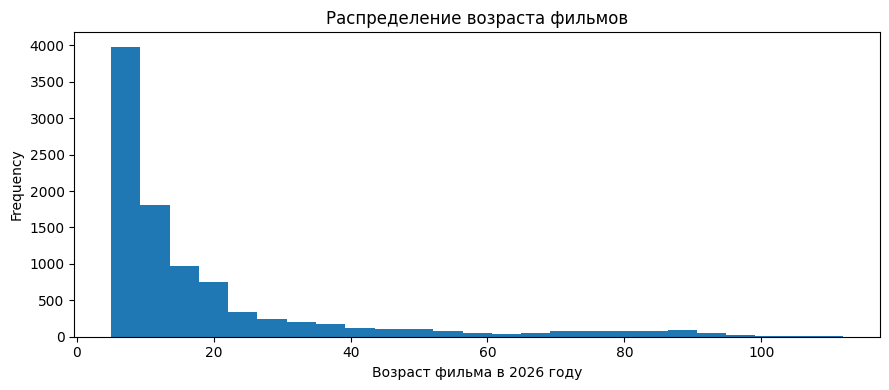

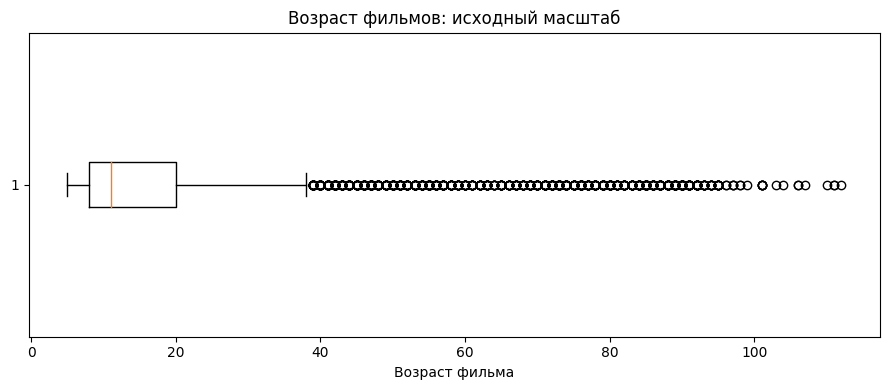

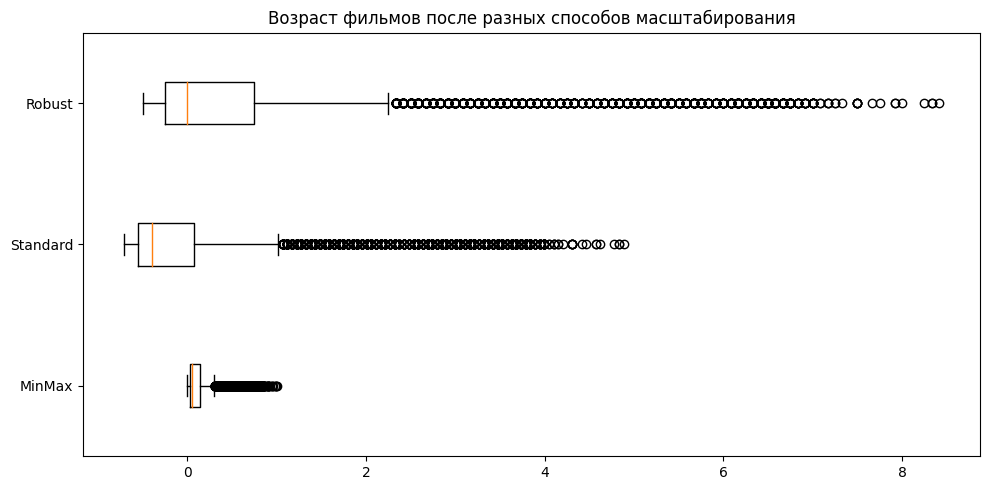

In [6]:
# -----------------------------------------------------------------------------
# Назначение ячейки: сравнить исходное распределение и результаты масштабирования.
# Гистограмма показывает форму распределения, а boxplot — медиану, квартили и выбросы.
# Важно: scaler меняет центр и масштаб, но не удаляет выбросы и не обязан делать
# распределение нормальным. Графики сохраняются в outputs для последующего отчета.
# -----------------------------------------------------------------------------

ax = X_imputed["movie_age"].plot(kind="hist", bins=25, figsize=(9, 4), title="Распределение возраста фильмов")
ax.set_xlabel("Возраст фильма в 2026 году")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "movie_age_hist_original.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(X_imputed["movie_age"], vert=False)
ax.set_title("Возраст фильмов: исходный масштаб")
ax.set_xlabel("Возраст фильма")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "movie_age_boxplot_original.png", dpi=140)
plt.show()

# Для одного и того же признака показываем три преобразованных распределения.
boxplot_data = [
    scaled_frames["minmax"]["movie_age"],
    scaled_frames["standard"]["movie_age"],
    scaled_frames["robust"]["movie_age"],
]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(boxplot_data, labels=["MinMax", "Standard", "Robust"], vert=False)
ax.set_title("Возраст фильмов после разных способов масштабирования")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "movie_age_scalers_boxplot.png", dpi=140)
plt.show()

## 5. Почему масштаб меняет расстояние между объектами

Мы не запускаем KNN или кластеризацию, чтобы не опережать будущие темы. Вместо этого сравним вклад признаков в евклидово расстояние между двумя фильмами.

,method,feature,squared_difference,share_of_squared_distance
0,original,rating_score,1296.0000,0.1012
1,original,movie_age,11449.0000,0.8940
2,original,title_length,36.0000,0.0028
3,original,platform_count,0.0000,0.0000
4,original,age_min,25.0000,0.0020
5,standard,rating_score,7.4468,0.1854
6,standard,movie_age,31.2872,0.7791
7,standard,title_length,0.3220,0.0080
8,standard,platform_count,0.0000,0.0000
9,standard,age_min,1.1045,0.0275


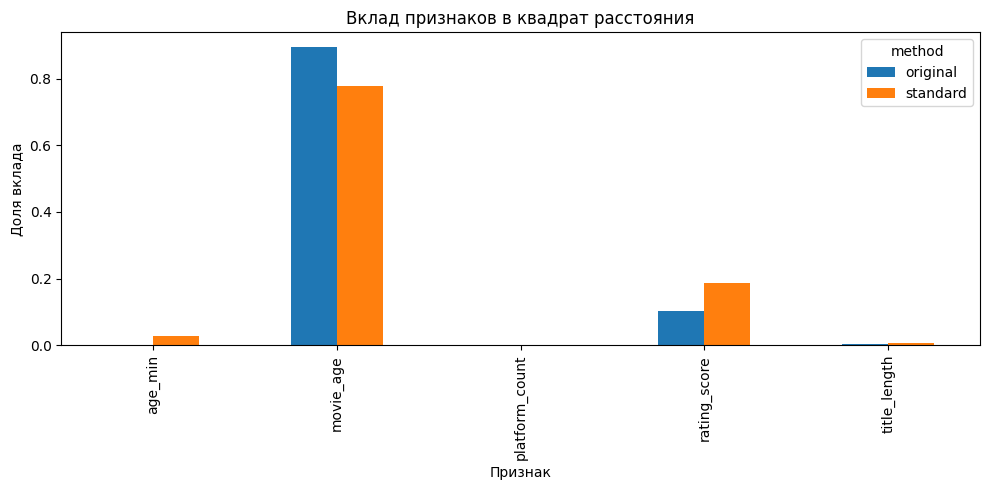

In [7]:
# -----------------------------------------------------------------------------
# Назначение ячейки: показать, почему масштаб влияет на расстояния между объектами.
# Для двух фильмов вычисляется вклад каждого признака в квадрат евклидова расстояния.
# Затем тот же расчет повторяется после StandardScaler. Сравнение показывает,
# как крупные единицы измерения могут доминировать без предварительного масштабирования.
# -----------------------------------------------------------------------------

# Выбираем два фильма с разными характеристиками.
first_index = X_imputed["movie_age"].idxmin()
second_index = X_imputed["movie_age"].idxmax()


def distance_contributions(frame: pd.DataFrame, i: int, j: int, label: str) -> pd.DataFrame:
    differences = frame.loc[i, feature_columns] - frame.loc[j, feature_columns]
    squared = differences.pow(2)
    total = squared.sum()
    return pd.DataFrame({
        "method": label,
        "feature": feature_columns,
        "squared_difference": squared.values,
        "share_of_squared_distance": (squared / total).values,
    })

contributions = pd.concat([
    distance_contributions(X_imputed, first_index, second_index, "original"),
    distance_contributions(scaled_frames["standard"], first_index, second_index, "standard"),
], ignore_index=True)

display(contributions.round(4))

plot_contributions = contributions.pivot(
    index="feature", columns="method", values="share_of_squared_distance"
)
ax = plot_contributions.plot(kind="bar", figsize=(10, 5), title="Вклад признаков в квадрат расстояния")
ax.set_xlabel("Признак")
ax.set_ylabel("Доля вклада")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distance_feature_contributions.png", dpi=140)
plt.show()

## 6. Нормализация строк — отдельная операция

`Normalizer` приводит каждую строку к единичной норме. Это не синоним Min–Max scaling и не замена StandardScaler.

In [8]:
# -----------------------------------------------------------------------------
# Назначение ячейки: отдельно показать нормализацию строк до единичной L2-нормы.
# Это не то же самое, что стандартизация столбцов: Normalizer обрабатывает каждую строку
# как вектор и делит ее на собственную длину. Проверка np.allclose подтверждает,
# что L2-норма каждой преобразованной строки равна единице.
# -----------------------------------------------------------------------------

normalizer = Normalizer(norm="l2")
row_normalized = pd.DataFrame(
    normalizer.fit_transform(X_imputed),
    columns=feature_columns,
    index=X_imputed.index,
)

row_norms = np.sqrt((row_normalized ** 2).sum(axis=1))
print("Первые L2-нормы строк:", row_norms.head().round(6).tolist())
assert np.allclose(row_norms.to_numpy(), 1.0)

Первые L2-нормы строк: [1.0, 1.0, 1.0, 1.0, 1.0]


## 7. Сохранение результатов

In [9]:
# -----------------------------------------------------------------------------
# Назначение ячейки: сохранить масштабированные признаки и диагностические таблицы.
# Для каждого исходного признака создаются отдельные версии minmax, standard и robust.
# Идентификатор и название фильма сохраняются рядом, чтобы результат можно было связать
# с исходным объектом. Отдельно экспортируются статистики и вклады в расстояние.
# -----------------------------------------------------------------------------

scaled_movie_features = movies[["movie_id", "title"]].copy()
for method_name, frame in scaled_frames.items():
    for column in feature_columns:
        scaled_movie_features[f"{column}_{method_name}"] = frame[column]

scaled_movie_features.to_csv(
    PROCESSED_DIR / "scaled_movie_features.csv", index=False, encoding="utf-8"
)
scaling_comparison.to_csv(
    OUTPUT_DIR / "scaling_comparison.csv", index=False, encoding="utf-8"
)
contributions.to_csv(
    OUTPUT_DIR / "distance_contributions.csv", index=False, encoding="utf-8"
)

print("Готово:", PROCESSED_DIR / "scaled_movie_features.csv")

Готово: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.4.1 Нормализация и стандартизация данных\data\processed\scaled_movie_features.csv


## Итог пары

Для каждого метода сформулируйте:

- что происходит с центром и диапазоном;
- насколько метод чувствителен к крайним значениям;
- когда его целесообразно использовать;
- какие столбцы каталога нельзя масштабировать и почему.